# Ablations (Fig. 4)



In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

def _find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'conf').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current working directory.')

BASE_DEFT = _find_repo_root()
OUTPUT_FIGURES_DIR = BASE_DEFT / 'figures'

# CSV-only workflow (no tree loading / recomputation).
PATH_RESULTS = BASE_DEFT / 'results' / 'polymerase' / 'results_deft_ablations.csv'
PATH_SAVE_PDF = OUTPUT_FIGURES_DIR / 'ablation.pdf'


In [4]:
if not PATH_RESULTS.exists():
    raise FileNotFoundError(f'Could not find ablation CSV: {PATH_RESULTS}')

print(f'Using results file: {PATH_RESULTS}')

df = pd.read_csv(PATH_RESULTS)
df['depth'] = df['depth'].astype(int)
df['isTrain'] = df['isTrain'].astype(str).str.lower().map({'true': True, 'false': False})
df['isTrain'] = df['isTrain'].astype(bool)
df['random_seed'] = df['random_seed'].astype(int)

df = df[df['isTrain'] == True].copy()



Using results file: /home/nvth2/deft_cr/results/polymerase/results_deft_ablations.csv


In [5]:
# Match method ordering and labels from the original ablation notebook
method_key_map = {
    'original': 'DEFT',
    'reflection_0': 'DEFT_no_ref',
    'no_prior_knowledge_depth_10': 'DEFT_no_prior',
    'no_adaptivity': 'DEFT_no_adapt',
}

method_order_keys = [
    'DEFT',
    'DEFT_no_ref',
    'DEFT_no_prior',
    'DEFT_no_adapt',
]

label_map = {
    'DEFT': r'$\texttt{DEFT}$',
    'DEFT_no_ref': r'$\texttt{DEFT}_{\texttt{no ref}}$',
    'DEFT_no_prior': r'$\texttt{DEFT}_{{\texttt{no prior}}}$',
    'DEFT_no_adapt': r'$\texttt{DEFT}_{\texttt{no adapt}}$',
}

df_results_final = df.copy()
df_results_final['method_key'] = df_results_final['method'].replace(method_key_map)
df_results_final = df_results_final[df_results_final['method_key'].isin(method_order_keys)]
df_results_final = df_results_final[df_results_final['depth'].between(1, 10)]
df_results_final['method'] = df_results_final['method_key'].map(label_map)

method_order = [label_map[k] for k in method_order_keys]
custom_palette = sns.color_palette(['#1f77b4', '#e74c3c', '#FFA500', '#2ecc71'])  # Blue, green, purple, red


/tmp/ipykernel_915743/3187592867.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df_results_final, x="depth", y="accuracy", hue="method", ci = 95, hue_order = method_order, palette = custom_palette, linewidth=2)


Saved plot to: /home/nvth2/deft_cr/figures/ablation.pdf


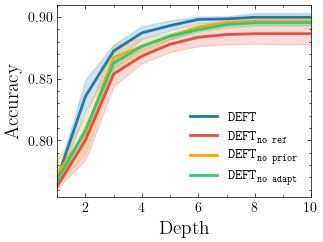

In [6]:
sns.lineplot(data=df_results_final, x="depth", y="accuracy", hue="method", ci = 95, hue_order = method_order, palette = custom_palette, linewidth=2)

major_ticks = np.arange(2, 11, 2)  # [2,4,6,8,10]
minor_ticks = np.arange(1, 10, 2)  # [1,3,5,7,9]

plt.gca().set_xticks(major_ticks)  # Set major ticks
plt.gca().set_xticks(minor_ticks, minor=True)  # Set minor ticks

plt.xlabel("Depth", fontsize = 14)
plt.ylabel("Accuracy", fontsize = 14)
plt.xlim(1, 10)

plt.legend(title=None)
plt.tight_layout()

#save
PATH_SAVE_PDF.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(PATH_SAVE_PDF, bbox_inches = "tight", dpi=300)
print(f'Saved plot to: {PATH_SAVE_PDF}')
plt.show()
